# Install

In [1]:
# !pip install pytorchvideo torchvision torchmetrics --quiet
# !pip install av --quiet
# !pip install ultralytics
# !pip install decord av

# !pip install -q pillow torchvision

# Setup TSM

In [2]:
import os

# Create the directory structure
os.makedirs('ops', exist_ok=True)

# 1. Create the Temporal Shift Module logic
with open('ops/temporal_shift.py', 'w') as f:
    f.write("""
import torch
import torch.nn as nn

class TemporalShift(nn.Module):
    def __init__(self, net, n_segment=12, n_div=8):
        super(TemporalShift, self).__init__()
        self.net = net
        self.n_segment = n_segment
        self.fold_div = n_div

    def forward(self, x):
        x = self.shift(x, self.n_segment, self.fold_div)
        return self.net(x)

    @staticmethod
    def shift(x, n_segment, fold_div):
        nt, c, h, w = x.size()
        n_batch = nt // n_segment

        x = x.view(n_batch, n_segment, c, h, w)

        fold = c // fold_div
        out = x.clone()

        # Unidirectional shift (real-time friendly)
        out[:, 1:, :fold] = x[:, :-1, :fold]

        return out.view(nt, c, h, w)
""")

# 2. Create the Dataset logic (Simplified for your CCTV frames)
with open('ops/dataset.py', 'w') as f:
    f.write("""
import torch.utils.data as data
from PIL import Image
import os
import numpy as np
import random

class TSNDataSet(data.Dataset):
    def __init__(self, root_path, list_file, num_segments=12, transform=None, train=True):
        self.root_path = root_path
        self.list_file = list_file
        self.num_segments = num_segments
        self.transform = transform
        self.train = train
        self._parse_list()

    def _parse_list(self):
        self.video_list = []
        for line in open(self.list_file):
            parts = line.strip().rsplit(" ", 2)  # split from right!
            self.video_list.append(parts)

    def _get_indices(self, n_frames):
        if n_frames >= self.num_segments:
            if self.train:
                # jittered sampling
                segment_size = n_frames / self.num_segments
                offsets = []
                for i in range(self.num_segments):
                    start = int(segment_size * i)
                    end = int(segment_size * (i + 1))
                    offsets.append(random.randint(start, max(start, end - 1)))
                return offsets
            else:
                # deterministic (first & last included)
                return np.linspace(0, n_frames - 1, self.num_segments).astype(int)
        else:
            return [i % n_frames for i in range(self.num_segments)]

    def __getitem__(self, index):
        directory, n_frames, label = self.video_list[index]
        n_frames = int(n_frames)

        offsets = self._get_indices(n_frames)

        images = []
        for offset in offsets:
            frame_idx = offset + 1  # adjust if your dataset is 0-indexed
            p = os.path.join(self.root_path, directory, f"img_{frame_idx:05d}.jpg")

            if not os.path.exists(p):
                # fallback to last frame
                p = os.path.join(self.root_path, directory, f"img_{n_frames:05d}.jpg")

            images.append(Image.open(p).convert('RGB'))

        if self.transform:
            images = self.transform(images)

        return images, int(label)

    def __len__(self):
        return len(self.video_list)
""")

# 3. Create the simplified Model Wrapper
with open('ops/models.py', 'w') as f:
    f.write("""
import torch
import torch.nn as nn
from torchvision import models
from .temporal_shift import TemporalShift

class TSN(nn.Module):
    def __init__(self, num_class, num_segments=12):
        super(TSN, self).__init__()
        self.num_segments = num_segments

        self.base_model = models.mobilenet_v2(pretrained=True)

        # Apply TSM to selected layers (not all)
        for i, m in enumerate(self.base_model.features):
            if isinstance(m, nn.Sequential):
                self.base_model.features[i] = TemporalShift(
                    m,
                    n_segment=num_segments,
                    n_div=8
                )

        # Replace classifier
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.base_model.last_channel, num_class)
        )

    def forward(self, input):
        b, s, c, h, w = input.size()

        input = input.view(-1, c, h, w)
        base_out = self.base_model(input)

        base_out = base_out.view(b, s, -1)

        # Temporal consensus (average)
        return base_out.mean(dim=1)
""")

# 4. Group Transforms
with open('ops/transforms.py', 'w') as f:
    f.write("""
import torch
import torchvision.transforms.functional as F
import torchvision.transforms as T
import random

class GroupTransform:
    def __init__(self, size=(224, 224), is_train=True):
        self.size = size
        self.is_train = is_train

    def __call__(self, img_group):
        if self.is_train:
            do_flip = random.random() > 0.5
            brightness = random.uniform(0.7, 1.3)
            contrast = random.uniform(0.7, 1.3)

            do_perspective = random.random() > 0.5
            if do_perspective:
                persp_params = T.RandomPerspective.get_params(
                    width=img_group[0].size[0],
                    height=img_group[0].size[1],
                    distortion_scale=0.3
                )

            w, h = img_group[0].size
            th, tw = int(h * random.uniform(0.8, 1.0)), int(w * random.uniform(0.8, 1.0))
            i = random.randint(0, h - th)
            j = random.randint(0, w - tw)
        else:
            do_flip = do_perspective = False
            i, j, th, tw = 0, 0, img_group[0].size[1], img_group[0].size[0]
            brightness = contrast = 1.0

        transformed_group = []
        for img in img_group:
            img = F.resized_crop(img, i, j, th, tw, self.size)

            if self.is_train:
                if do_flip:
                    img = F.hflip(img)
                if do_perspective:
                    img = F.perspective(img, *persp_params, interpolation=T.InterpolationMode.BILINEAR)
                img = F.adjust_brightness(img, brightness)
                img = F.adjust_contrast(img, contrast)

            img = F.to_tensor(img)
            img = F.normalize(img, [0.485, 0.456, 0.406],
                                   [0.229, 0.224, 0.225])

            transformed_group.append(img)

        return torch.stack(transformed_group)
""")

print("✅ TSM structure created manually. You are ready to train!")

✅ TSM structure created manually. You are ready to train!


# Imports

In [3]:
import os
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from collections import defaultdict
import torchvision.transforms as T
import zipfile

# Setup Raw Dataset

In [4]:
# import os
# import gdown

# normal_files = {
#     "10_00.mp4": "1ErJ3lhVeya_CNnm-VtUxUSf-EftIJgH-",
#     "10_01.mp4": "1fr8XvpeaU9rcAHceQYiiMjdaPUaJyVHQ",
#     "10_02.mp4": "10IY-OxVom0fzZBa6dpLdqlcSF1gHFZf-",
#     "10_10.mp4": "1TX5utr4huocVEUb4PsvDv9Vp72qO7YnY",
#     "10_12.mp4": "1CySJZeIp4dquYB90ca8tvLHKYIxdG7_h",
#     "10_20.mp4": "1swXIus9-rQLQT_KvhJ4F3T0a8VBiQGyo",
#     "10_21.mp4": "1FsL9dbTxM2dN8R_z5-XBPIqQVRMdH9Tu",
#     "10_22.mp4": "1Siu--zZOwt3xyF_T3AF7tYmPNOEJnrLt",
#     "11_00.mp4": "1FWvmPdJOuxsLqAvlHIzJ3PWU5hMjsjEI",
#     "11_01.mp4": "11AF6jFRWZ0xKk4mQYRkIl3K3piMOg1KU",
#     "11_02.mp4": "1U47UDzyj8s3PJnsCQJv7BBYZnnOqxKeI",
#     "11_10.mp4": "1dx2pSNRzVU8AMywLjBar750gvzKwGpgZ",
#     "11_12.mp4": "1C0cREUhRDLxY47y57IXCXIRnTZEOeuhP",
#     "11_22.mp4": "1kB_o3tgzw2dGS0U0wW0M9vbRAyrqA5re",
#     "12_00.mp4": "1Wl76NzAhh3FHQFniI6DLzubjincd3eIT",
#     "12_01.mp4": "1_fO0ff6uqpI1t_x-zOIhxs8-5r4Tl1IP",
#     "12_02.mp4": "1yAmYav-zaB5v6rZscqttgoYAMAcCYVe8",
#     "12_10.mp4": "1tXMCSMaTKBjGIFPS-JrbEURLxgLq71P5",
#     "12_12.mp4": "1r3sazTFhOx_gSLDqhoXHP9Z_T9pnpYAI",
#     "12_20.mp4": "1pjRPrDE4FpdrNyvR0Qndk_92RVwkZh2V",
#     "12_21.mp4": "1WD_ZdYmDHh26ALNMvmlrJmgm2h8zYorV",
#     "12_22.mp4": "1pUMSvhGEEqCCKfJbEXu58EtSTFaPIOfh",
#     "13_00.mp4": "1GvExYPXQuLLTqYOZOWSzRLkmvt82z5RU",
#     "13_01.mp4": "12VkFZHaDjz4LPrPsyuxabP4BaKQrE9YC",
#     "13_02.mp4": "1Sw0Ocj6Y_Q62Kdg_6smj0pjNUdfzhcsX",
#     "13_10.mp4": "1l1hJGMk2IuWdZofUMZRqRaW7l8MdlRMQ",
#     "13_12.mp4": "1YR5Mdz0u_kE5Qsl0BySVKoDLyveF8jA-",
#     "13_20.mp4": "11kD8WrtOqhU5U-xAsOFjzXC-1jCj6rmJ",
#     "13_22.mp4": "1hESbxsYZd4DJ1EhRbja84_8kkjwptF4H",
#     "14_00.mp4": "12GJTtD2-HPzIAJegAVGm6fuD4JXOj9Ss",
#     "14_01.mp4": "1Gf66uRNqlrm0A1HupDdioeNILAntG_Ah",
#     "14_02.mp4": "1IgDIjNj2jnZXyZ6K7Ld7iBVCH7mcZGsY",
#     "14_10.mp4": "1Kgr2Av1O2Bfy-_we-XPT9xefX-46djhZ",
#     "14_12.mp4": "1S_mMfMND4aU8yN1ipTRUy8dVfAYwA2w3",
#     "14_20.mp4": "1TQ8b_w0bnZK9Rd0KX_mZG8m-qAv-jC0V",
#     "14_21.mp4": "15wQlBHGyRUtHU1W_0aihBKC51798WSwU",
#     "14_22.mp4": "1owITi-OeOAU7dCggFNXIRJdWuxjaMnCY",
#     "15_00.mp4": "1mzHXKU28qMNTQUjyYKB6F2wvTP8MtEtN",
#     "15_01.mp4": "1GWjQamu335h1qsd8rkK42QP9ToP5CEfM",
#     "15_02.mp4": "1GCcppc9qeJKD4PMLMrOMsw9nPuSrHz6c",
#     "15_10.mp4": "1cXde6-25jbBuOxFT6V2ZO_qeaefTtVV_",
#     "15_12.mp4": "1B6ymgTeBa5nRxXN4R8Ea_YwPTZsD-hrn",
#     "15_20.mp4": "1ANuDt-PON79gd_1taAuQ56xV3WkKjoZ1",
#     "15_22.mp4": "1emNX7VXjXAuath0f9Iw29vItGOiomM4q",
#     "16_00.mp4": "1aImWA3a10xTcA5571Uun6xLSAiKWcOKk",
#     "16_01.mp4": "1DaVd67m-pbr_H5my4MgPUxK4ncO-RxaH",
#     "16_02.mp4": "1yr-0wl9y6XDJxCaoQN6f0-BfcIBgbsMG",
#     "16_10.mp4": "1xAcyErRqegpFBDlhj176-npcwwtkWvQs",
#     "16_12.mp4": "1g5W7_KR-SmYmzAZKqKQ1viUZkH1JGyO8",
#     "16_20.mp4": "1w2zEfn8oOOggH5qg8Tk4FIURQ5UZ36-C",
#     "16_21.mp4": "1dZjaZsXKXNtkDhQbyFeXEY3VnLiXLyEl",
#     "16_22.mp4": "1-qpigY62rVbv4vD9TpGFLaxw1uizqa4w",
#     "17_00.mp4": "1qV8pFG5hvUc9Zh14MHJqyeqVvR6ywgMy",
#     "17_01.mp4": "1h6pVecmbzk9FvzOTB03DDusccwXjOyTM",
#     "17_02.mp4": "1GAg-gfwIMnvSy4JDfL01eaH9oESJlkkn",
#     "17_10.mp4": "1TfTac0yzNK52wpILGs8XPC5RmRcUXRfP",
#     "17_12.mp4": "1WCQiQ3jG80D3ofhNloBNVb3VlyvOlbn1",
#     "17_20.mp4": "1pCDtgzNu_sPovuiEFVfrzLwHyvqkopYQ",
#     "17_21.mp4": "1dQ4xIYBm61YCi4YJWH0CDYX_8C3_Cb1v",
#     "17_22.mp4": "1R4MjFtJss-ow9S2Xlx-DNzQGQu5jwRXW",
#     "18_00.mp4": "1vGeeKSqrb12boRHPRwdlS9Yr2zadYf_n",
#     "18_01.mp4": "1EDl_YrgSUaWVQNAP7kLha2SgHWZlLO1c",
#     "18_02.mp4": "1CcYJFAkvvIxzzf3DZnAuGTlvsiv1-vPJ",
#     "18_10.mp4": "1wcKgUlXnv8Jb0YlNatbxzVbjxS8A8FUF",
#     "18_12.mp4": "1vs52dZVC7FDWyYbRDbEf0mZeulazq_Fq",
#     "18_20.mp4": "1D-xE-wwIeSL-epqtaBxI2yTNf3AP_vB5",
#     "18_21.mp4": "1FV2dfy-ayu3geIxRoH9sRkb98POlrid2",
#     "18_22.mp4": "1iIGeQwHX4hjXHGR6ibqjlSYORnuCD2a1",
#     "19_00.mp4": "1yNmxfgoDhwO07fGutb8UiScg9rEfkmXr",
#     "19_01.mp4": "1e0u2IMG630OBT0KubXkzCu081YHaLX-5",
#     "19_02.mp4": "1xvZsAbwSgc-zNOPO7eljPHV4ttB9R3VO",
#     "19_10.mp4": "1_GKJcTMTyhO4REj7NwiI_76P57KOWmqr",
#     "19_12.mp4": "16uh7o6Y1kvJ8nPHy_lNMXsX1N1Ob2C3Z",
#     "19_20.mp4": "19GP6jb-ZRMpuXbCmygDw7zMwE6IblYHZ",
#     "19_21.mp4": "1LvAOr44rMiW_9ajs82Im3cgAaOUjM-NJ",
#     "19_22.mp4": "1zyeuAftn7JEMTi3CrX9gyYwQqzjORdtJ",
#     "1_00.mp4": "1wFZj2zb_EtQ2trsvvDwr48l7VdtargLw",
#     "1_01.mp4": "1WdXARJujQCFBVMflCTsyv2muhmp3yDQB",
#     "1_02.mp4": "1pdyvoGu-AXo_85XDvADw-rYKHZq5vY7r",
#     "1_10.mp4": "1SXv6_t5ScaiOkTdnptMQOre2NGqD6t6C",
#     "1_12.mp4": "17egy5NjObOREOs-Be8-dn93ruYC4xqAY",
#     "1_20.mp4": "1IcrpGdORomdfWDSrXKROykLgbM41uOYj",
#     "1_21.mp4": "1EwRfH6zn7gzk3X4nVlXPwU4R4981vSUb",
#     "1_22.mp4": "1YKFthXgba38-DDlbmTjMG5j-zI0mwIg7",
#     "20_00.mp4": "1CR5D0wSvmP_M7Y5lWRpBDqsS97zBr02w",
#     "20_01.mp4": "1gu_M6YTyjV-QbGFeZEhnK-mbMlCOp7nx",
#     "20_02.mp4": "1ywq4dlZaaZvZszrrgH5-TyD5ZkvcIGn4",
#     "220298ed-0a4b-4316-b297-4f7d37e04449_00.mp4": "1kwBpD_uVu_nWlrRx5rVDwctTP3y8MLUI",
#     "220298ed-0a4b-4316-b297-4f7d37e04449_01.mp4": "1z795QeKx5WtoVeKvRzCjk3OjSqsw8w1Q",
#     "220298ed-0a4b-4316-b297-4f7d37e04449_02.mp4": "1d5r3fICz5bsQOxi-S6uyQ1YDzjuyHUjA",
#     "220298ed-0a4b-4316-b297-4f7d37e04449_10.mp4": "1StVS14ki1KMlqMAfq7SGh0I6hxrm_0D-",
#     "220298ed-0a4b-4316-b297-4f7d37e04449_12.mp4": "1_Ho_N_6-7Ca8kfFB3x2iP141xmpGcs83",
#     "220298ed-0a4b-4316-b297-4f7d37e04449_20.mp4": "1bsk6tK8qNzx9MJpNrEJey0HbfJ25XJG3",
#     "220298ed-0a4b-4316-b297-4f7d37e04449_22.mp4": "1fDrZUHMjhGtN9tdw7mBzkoCEjg6eEs42",
#     "2_00.mp4": "1d5bBGrtcbKoeTJ6JC5BdfCLMiRAdthhA",
#     "2_01.mp4": "15VHGrCqOlUKp_8swZPHTrxx5CgZg9p24",
#     "2_02.mp4": "1I6a_b8ml0UMj-9KjZ4DshSkpiJY3pV5s",
#     "2_10.mp4": "1rD2q3SBbGLAo7sjWPp_K8YtsPi66VrnJ",
#     "2_12.mp4": "14GlQ7O9Hwzwxz8BQaFnWP7rZixL7Z3Ym",
#     "2_20.mp4": "19FCySsBG5TA32gwpXZ6cZ46QHzl_ERle",
#     "2_21.mp4": "1D3RvK5Ro2HuAIjgarPGf87eAzPR-xt43",
#     "2_22.mp4": "1BLdKsS6YRMzXNpp3RSIa4DNrWHDbEr6M",
#     "2b4c6a9f-3689-4341-8f98-0ff14e6428e0_00.mp4": "1pvmT1l5bbpE9hoOTnLFHyIt6Rwl_UAxi",
#     "2b4c6a9f-3689-4341-8f98-0ff14e6428e0_01.mp4": "1F7Y_eiJtdYpG19Y_uSv_pkSPfsrkMHEd",
#     "2b4c6a9f-3689-4341-8f98-0ff14e6428e0_02.mp4": "1iIHcANQDTaAYdKrEcR1uv7plEMOwm_tV",
#     "2b4c6a9f-3689-4341-8f98-0ff14e6428e0_10.mp4": "1GVUTF3FlAUupu8cQLf7j6ru6YiLKJ1ch",
#     "2b4c6a9f-3689-4341-8f98-0ff14e6428e0_12.mp4": "16U8GgUmsb3rssVT1AqP_x07TPrsYMEj0",
#     "2b4c6a9f-3689-4341-8f98-0ff14e6428e0_20.mp4": "1mV4DWsgLpD23uUAf7EHIpMyoX6yOhLR1",
#     "2b4c6a9f-3689-4341-8f98-0ff14e6428e0_21.mp4": "17DAPDavNemP955vyDhi81So6Oj3wQaXd",
#     "2b4c6a9f-3689-4341-8f98-0ff14e6428e0_22.mp4": "1pzwL5_MuJgT3nxfGK4YQ25t4ejsoiHct",
#     "31cd3a1d-9b26-4432-a1f5-199df0cb9d12_00.mp4": "1YAui6hq4kCZ1I1NLtpAOgADPLyRED1H3",
#     "31cd3a1d-9b26-4432-a1f5-199df0cb9d12_01.mp4": "1LqkzhdALs24TNlcqvil9WkhE8-Qdi1bH",
#     "31cd3a1d-9b26-4432-a1f5-199df0cb9d12_02.mp4": "1RCg8ry74Ijb3QopkPZsbDNocIjJmP4XR",
#     "31cd3a1d-9b26-4432-a1f5-199df0cb9d12_10.mp4": "1xcgO0tuM-fzEaKEOBzYK2dMdqaXBywyB",
#     "31cd3a1d-9b26-4432-a1f5-199df0cb9d12_20.mp4": "1yZ35wZv5AHJmhTyqt3n4PJnM6bqw9KVx",
#     "31cd3a1d-9b26-4432-a1f5-199df0cb9d12_22.mp4": "1tMfrPVs7o60fiHlQQjHl8_pAP-Nzpyoj",
#     "3_00.mp4": "1Lik5P2otPMRYEiXtu9vV_x_WGb5Dymdp",
#     "3_01.mp4": "1PokcTT1BC3xVenSfl78hfltZQFXGOHgE",
#     "3_02.mp4": "1-qPUco_QA7tdEVbR8BD3gMaKkGIBt-yO",
#     "3_10.mp4": "1X_xsXMPLYPxInGdQunkNZ3fdAUfL_xeJ",
#     "3_12.mp4": "1wCOEjiYCSMN5IHtN3Zsux9WEGUm1lryp",
#     "3_20.mp4": "1H9HwgEvUK2p0i5mBMp8J6CtyYgdITDpR",
#     "3_21.mp4": "1LqX12a8XpIgVM0V3UVJko3uEjZ_97sC4",
#     "3_22.mp4": "1_hqqVYPWwyyBMfTvAQz-sCPd0jtJiyNr",
#     "4_00.mp4": "1ATMg0MCLm-2-FsNAeDKKrkND4vNxuG_2",
#     "4_01.mp4": "1jFsLk6VcxoRDGk_uW0vRvVDpzEuaXTH9",
#     "4_02.mp4": "1T4X7pjbAYMMHCfVuzCv_OUqxnl9tTL-I",
#     "4_10.mp4": "1lNEIfUgwtpCvePiqrsGbcMRo-BBqWxhs",
#     "4_12.mp4": "1ULXisejjrVavtFAxJ9l2SrluXEhDkvif",
#     "4_20.mp4": "18Vbv56H6A20OKy4hMdY7efnRgGiyu2Dh",
#     "4_21.mp4": "1hLrJxW_KxosJglvn85TrwcoAeg0_1krP",
#     "4_22.mp4": "1mkYfL2Q0Ym-D3ZmR81nxr3Qkhce6W5oU",
#     "52bb16d1-da06-4005-91bf-e62fd6174c40_00.mp4": "16IuiUz9Uuu2r8X_eazjOYv3mAJgC0Oey",
#     "52bb16d1-da06-4005-91bf-e62fd6174c40_01.mp4": "1V8mHqVWPJ3qyEfL-nXfzcf_72s453moB",
#     "52bb16d1-da06-4005-91bf-e62fd6174c40_02.mp4": "1gB3fzmWyiyIQz2QkLTx2P8dNMIvbFxYi",
#     "52bb16d1-da06-4005-91bf-e62fd6174c40_10.mp4": "1YRd73LICQF-ytAH-KBIetkS_WQwfdzED",
#     "52bb16d1-da06-4005-91bf-e62fd6174c40_12.mp4": "1-G0R81tW9guc13ictr5O5HzYYS86JBt2",
#     "5_00.mp4": "1Y2o_bLUtGeuIdiRA__sQAtrVs2G_dfbV",
#     "5_01.mp4": "19ow62N5gZWIPCzJC_2sNNSql9L8xK-22",
#     "5_02.mp4": "1CQiW7flSL654BwIZYof9Pdh37KK90WI7",
#     "5_10.mp4": "1kfK8hULgJzYlxF_ygw4di2z4r0JuVbIq",
#     "5_12.mp4": "1HwSL9Nb2WNAprk4R8wKfWQBoQlVMu9uU",
#     "5_20.mp4": "1W77R0Ip9o1k0h94Ys9JOR46ck_9Ce7kA",
#     "5_21.mp4": "1S_MyxkzgUFbWk5eMOU1dEXZQJhDQthUb",
#     "5_22.mp4": "1p7-Ja9SF1MVVIUovcgdBWzS2kvZNWQjh",
#     "6d8dd595-7573-4a9c-8436-83290c2eb689_00.mp4": "1p7HJ7JgXpWdod5e5OjSjBrsHjVAgVRlj",
#     "6d8dd595-7573-4a9c-8436-83290c2eb689_01.mp4": "1lMVxeANzaZr5A0WMkPy8CZagCiqZ0UUB",
#     "6d8dd595-7573-4a9c-8436-83290c2eb689_02.mp4": "1jl0jNCnUVOJtm3HhHA8JQAF4qGrqWrkK",
#     "6d8dd595-7573-4a9c-8436-83290c2eb689_10.mp4": "1B3PXr4VKj1um7ZzAhNAsj04C954V2OyN",
#     "6d8dd595-7573-4a9c-8436-83290c2eb689_12.mp4": "1So3s776-5Hry0LcJ3qUvZJ5vC8w_5bgS",
#     "6d8dd595-7573-4a9c-8436-83290c2eb689_20.mp4": "1DbGbvsCBKXb7KN-9RXi83MSD0ZUcMDSQ",
#     "6d8dd595-7573-4a9c-8436-83290c2eb689_22.mp4": "1WPCctSwUr59Y-EcdIb7IbCLGSHqgoG4m",
#     "8_00.mp4": "1lRQbtZcutrYKy6zj6NuOQ2PQ54OYFov9",
#     "8_01.mp4": "1hbS2-uT2oocqG30wpPR7VOrQxhzua6Xh",
#     "8_02.mp4": "1lxuGA3PmDn5Zjvu3mJToOMr1fqq-8O2W",
#     "8_10.mp4": "1rhQUSnHb6hg8u3rkyL6MsAmp_YqBzxQ_",
#     "8_12.mp4": "1ClWCbw4Mi5cAm72LNUgTKnE_2wiwN44t",
#     "8_20.mp4": "1cOSrg-lC_Tp78t7CPR8EU9gxgongqlLI",
#     "8_21.mp4": "1wiVqV1NCNQ2RZmzn8rWKAipbuFctYJR9",
#     "8_22.mp4": "1byC9qvhLWCpj_wpBG7amOOdEPcSeaNPS",
#     "9_00.mp4": "1-QiRnlzw1BnkeijpwE4XZxrra8HfQgqu",
#     "9_01.mp4": "1wfxPnI-m_uDcbkj-rpXAHyBU9llQlzgw",
#     "9_02.mp4": "1H_ClqfwUcnksHE_e02TQCFScYWNLnDC7",
#     "9_10.mp4": "1CuMWVjL7ZAl9Tg8xRPb2vQe1nsGT_0as",
#     "9_12.mp4": "1FK13mUFqAy5oyptj9ocH4mgSLZDzIQo7",
#     "9_20.mp4": "1vXW5b2KUpSIAycwOSZ07fNAAG6XiLdrI",
#     "9_21.mp4": "1tOvofxX3A229PwJFHCH_LO86rmVN-oDp",
#     "9_22.mp4": "1yxJcpgDRnfYihS_JJSbv2m_7AA13E-aL",
#     "ae761496-6225-4a67-b7e7-97a657bce252_00.mp4": "15NpiWdnrbeYk_w7ONuUl0Zr3Hc216XbQ",
#     "ae761496-6225-4a67-b7e7-97a657bce252_01.mp4": "1m7VSHflEKVbh5voz0W3K6pLOvOP2E8nS",
#     "ae761496-6225-4a67-b7e7-97a657bce252_02.mp4": "1oxKA5gfDh5m-1ak4s5kk4OgtaMIHQXcA",
#     "ae761496-6225-4a67-b7e7-97a657bce252_10.mp4": "1Xv_2xCmSWY1vQEOtQZTE1fRNjkImrH8M",
#     "ae761496-6225-4a67-b7e7-97a657bce252_12.mp4": "1iyYhhYWpMXsKdFCLYUNgJL2HxsT_-Wt2",
#     "ae761496-6225-4a67-b7e7-97a657bce252_22.mp4": "1A5W6UaaSasov1flyCx6-5ZH0FDRSJeeU",
#     "b6b7c7f2-e7e3-4909-aedb-1105d7bddfc1_00.mp4": "17vQSBzRYt7V5zR9XzFAP909Y0ESEJggw",
#     "b6b7c7f2-e7e3-4909-aedb-1105d7bddfc1_01.mp4": "1yPPIH4j4BLthTydgLKgdC2Lj0vMfNU-E",
#     "b6b7c7f2-e7e3-4909-aedb-1105d7bddfc1_02.mp4": "1tK-CRa0Rs2_Mc-v2yDeinxu05k6NqbTR",
#     "b6b7c7f2-e7e3-4909-aedb-1105d7bddfc1_10.mp4": "1b-l3borjDsyZIV0ZWDgrRB_vrAkwSJAU",
#     "b6b7c7f2-e7e3-4909-aedb-1105d7bddfc1_12.mp4": "1_zRYJL-9A6KZqBjxOUzuBdTfEbYuMh4I",
#     "b6b7c7f2-e7e3-4909-aedb-1105d7bddfc1_20.mp4": "1KAOWxxKrWiNpk3IbObNGMRnLmSl2sGxO",
#     "b6b7c7f2-e7e3-4909-aedb-1105d7bddfc1_21.mp4": "1GzrbAJIKzq6QWnWt1uQa-67xIqiJ0pB4",
#     "b6b7c7f2-e7e3-4909-aedb-1105d7bddfc1_22.mp4": "11rbWVxFjg2pFf58mIJAkpWbEyVQu7KD8",
#     "d3051f8e-9b02-4c6a-9adc-f2b0525b230a_00.mp4": "1OgL4xCb-bVJfDSd8jABHDXVDWfeAMWn4",
#     "d3051f8e-9b02-4c6a-9adc-f2b0525b230a_01.mp4": "1Ln4H1pgrVqpF58alJVpdFLekrnaZQNVX",
#     "d3051f8e-9b02-4c6a-9adc-f2b0525b230a_02.mp4": "1pEsAhjxpLjOWNiX-S4ITY23dY_EG60Kl",
#     "d3051f8e-9b02-4c6a-9adc-f2b0525b230a_10.mp4": "1lp-oioXcoWaSecZqzpPzy7CNYHwDLzoM",
#     "d3051f8e-9b02-4c6a-9adc-f2b0525b230a_12.mp4": "1NzAK-rq5DN0u1xPh-ikd_SsP4Ang2BWi",
#     "d3051f8e-9b02-4c6a-9adc-f2b0525b230a_20.mp4": "1pEofOlT2xrf1zgIn--bWEuU2bal-thvf",
#     "d3051f8e-9b02-4c6a-9adc-f2b0525b230a_21.mp4": "1rts7_ECV7NKBUCRX9c75sfkif94za4PZ",
#     "d3051f8e-9b02-4c6a-9adc-f2b0525b230a_22.mp4": "1vzZxCrCczhH39rxNFedhd0xryF9-4PnY",
#     "ee599a5f-1cf8-4d86-b018-6c20542fe9c6_00.mp4": "1Ecm3C-AP8HwrocCZJMQGfbTpU0uFWW1G",
#     "ee599a5f-1cf8-4d86-b018-6c20542fe9c6_01.mp4": "1lYX66qTn5RRQLcb6pAvb_b2GL7OYTCtM",
#     "ee599a5f-1cf8-4d86-b018-6c20542fe9c6_02.mp4": "1EGML1lrPwa78DtCxoqmjKLsmoHgwfN5L",
#     "ee599a5f-1cf8-4d86-b018-6c20542fe9c6_10.mp4": "1wf8TsdubeGHxiJ-kb7fo7xqR-zaMwCV0",
#     "ee599a5f-1cf8-4d86-b018-6c20542fe9c6_12.mp4": "1eER_PlIW1ZBKkboOXpHy5Qx-rrdXSNsE",
#     "ee599a5f-1cf8-4d86-b018-6c20542fe9c6_20.mp4": "154BpCaIum27HOBn-NZnHwLa_IbWWkNzR",
#     "ee599a5f-1cf8-4d86-b018-6c20542fe9c6_22.mp4": "1nR7qUaGTlbn5fLxWmHHH6Y1i913quBck",
#     "f2941ff0-a411-422c-8f8f-0d77f295ac45_00.mp4": "1QYx78HOKtTX5Np35HKRsHoj7GHMOrUI0",
#     "f2941ff0-a411-422c-8f8f-0d77f295ac45_01.mp4": "1yMSPAf0qrYOcrIhp0RTdugqUIcsuC-6K",
#     "f2941ff0-a411-422c-8f8f-0d77f295ac45_02.mp4": "1Eg2rja8mLGsV5GeiXy_t_fNnboSqYpSe",
#     "f2941ff0-a411-422c-8f8f-0d77f295ac45_10.mp4": "1lisNv2SIIvefiHphLV1lIuzEDv2OoN1E",
#     "f2941ff0-a411-422c-8f8f-0d77f295ac45_12.mp4": "1EY3gEbnaCtJV6KuiU84lsmWUgyL6oDvx",
#     "f3bac359-d087-45c4-815b-8758839901d0_00.mp4": "1jxcraUISwGGr-tH00LW9IwKVRkoM0Q4P",
#     "f3bac359-d087-45c4-815b-8758839901d0_01.mp4": "1DiVSnpSxd-9d1ZkW6l5j4gaTXEe7iTiT",
#     "f3bac359-d087-45c4-815b-8758839901d0_02.mp4": "1vfY9mY5X-6-_4wQ7C9-bKHC555nnXnQi",
#     "f3bac359-d087-45c4-815b-8758839901d0_10.mp4": "1IUvCE7R6OEPsIQzUBHDJXRVxyDttGg6Y",
#     "f3bac359-d087-45c4-815b-8758839901d0_12.mp4": "16s266Pp_4PJ0YZIfhtHIhuHalMM8Ine9",
#     "f3bac359-d087-45c4-815b-8758839901d0_20.mp4": "1NNOQzYzZYgWWpB8_TLWgTkd3h74q3cPM",
#     "f3bac359-d087-45c4-815b-8758839901d0_21.mp4": "16-xHRLcTwZ37y5ZR5-tddoHkebSJB72p",
#     "f3bac359-d087-45c4-815b-8758839901d0_22.mp4": "1OeO9OwX-PsV1f4HiOIwWyKgQnut73JO7"
# }

# violence_files = {
#     "051d4400-17a8-406f-ac47-7f8eb516a1b6.mp4": "1aG5Nu8faUfZbVjW3B4wmmNks2yaIruFH",
#     "06f4fb94-594e-4065-b332-5495aeb5c623.mp4": "1SejJD-2ge5mfDqBnX_ROJtBgdMNURhGZ",
#     "10_center_large.mp4": "1ZjCE1valM9aOMpXpkhRuaFHxi4oXLeG3",
#     "11_center_large.mp4": "1tifflYX2TyY4SOLmXAOIclet6HF0Pnqx",
#     "12_center_large.mp4": "1dWh1DfjnG3gd4hoaM_VobNDPb-VG86Ub",
#     "13_center_large.mp4": "1ujXy-kpUdUWSsV-y4WjL9ynBG1ZbAOWh",
#     "14_center_large.mp4": "1PvOzuRJpJoKfqo0fQkW0k4l5u4EKrQDu",
#     "15_center_large.mp4": "1aQb3kjDGdA5TpfffF4JPHsLQJsUkZuiO",
#     "16_center_large.mp4": "1iHd-uIUSZ2LjupW0_9q5snVFn9WLqvIf",
#     "17_center_large.mp4": "1vpUHKNnShSZalgtxL7LSOdMo2p8WDAJH",
#     "18_center_large.mp4": "1V5thUzK3EUxlT-cXL0n2xtRKfFNTqyMO",
#     "19_center_large.mp4": "1Va5MLp8dTpZOX8DGprD2S5FiSBlPCMk_",
#     "1_center_large.mp4": "1W89hHgImfVKemEb0qcFFigMLqrNRLpUS",
#     "20_center_large.mp4": "1TlIrhSg7frYJs-zngWbHzVRaUs4yDjA3",
#     "220298ed-0a4b-4316-b297-4f7d37e04449_center_large.mp4": "18xxTpV0KjQS7cVCgpDKz245EOtBkMljb",
#     "2_center_large.mp4": "1oh0XZ8Xh0O-aKuxCNsA3Z2bgRcggl3YM",
#     "2b4c6a9f-3689-4341-8f98-0ff14e6428e0_center_large.mp4": "1xH-aM8-yMg7Jw1P4jBk2nATY8mBkpmFV",
#     "2e4ca0b6-5163-4a0d-8f4c-e5036c75bc8a.mp4": "1rOoI6yuHWNXfDqpZyoMTSlT4YRP7otqC",
#     "2efc16ba-5932-4760-9474-3b8511c785df.mp4": "1HCnwkJG25UEL97slos900lXAtJaEoedC",
#     "31cd3a1d-9b26-4432-a1f5-199df0cb9d12_center_large.mp4": "1_a22yCQrts_e_aV_uJ2-tCyAmwnxEy0J",
#     "37da4589-00f1-4c49-a446-ceb9bab98579.mp4": "105RuPB7VM9S3hM8a9otCVeKSRPkoK0Ug",
#     "37df2430-6e9c-4c81-a553-f914a55805fc.mp4": "1r-oMgH41WPyGQGqg34iWkIwtZjfz26fp",
#     "3_center_large.mp4": "1MatvGZc-_c4ugrB1f-peloFSepNZ9yIp",
#     "4_11.mp4": "1FSlJ3T1SAP4GofLVfRl64-L4feomNvBU",
#     "52bb16d1-da06-4005-91bf-e62fd6174c40_center_large.mp4": "1GuHBJZBS1OKyNzCSAWPu8zXSN4DXnOe7",
#     "5_center_large.mp4": "1coI1pG3qlxEBEoXvPyLKU4BU7ywP6ufx",
#     "6.mp4": "1cwvOLQYmHHcY2HOoOh6wQZAvsPkcsNtW",
#     "6d8dd595-7573-4a9c-8436-83290c2eb689_center_large.mp4": "1HUYD4cyoobopTMqUKIdL3olGj3C6t_Bu",
#     "7.mp4": "1G1cnFV-mE__tRddAaCpqwUCHPbuX4iEi",
#     "7b03c5a5-e7b7-4c4c-b566-df2857172398.mp4": "1WAq6plGH08dUeK0qDlofyYJNkheLh5zV",
#     "7f06271c-fdb8-499d-a0c0-a384914f0fb0.mp4": "1Ii1OS0LHS2rTe8UvsuXTuGiv4NlWSvtV",
#     "8_center_large.mp4": "1p6ayNiEFDeajCKQNZ1ghhj9uBQCQam0l",
#     "9_center_large.mp4": "1FUqJhu9eCywGRSerdTWXLQT5iCOL57G0",
#     "a6dbb850-9c71-4cc9-9df6-fe07057336a3.mp4": "1tthqamCH0Gf90cTOtqTkb8vQQX1tCagh",
#     "ae761496-6225-4a67-b7e7-97a657bce252_center_large.mp4": "1aUdRA686UcpUid1StMwYH77W8vMWZ1SI",
#     "b6b7c7f2-e7e3-4909-aedb-1105d7bddfc1_center_large.mp4": "1ikJQ9I1atkspTqHag1DjYp7gd1x4QzaJ",
#     "d3051f8e-9b02-4c6a-9adc-f2b0525b230a_center_large.mp4": "1ZfGsT_8Xq701TaMggqrovIX7IgpSjN1M",
#     "ee599a5f-1cf8-4d86-b018-6c20542fe9c6_center_large.mp4": "1GTxK70loq2-5VWvzZrCjXhKIX1Xrtl-_",
#     "rn1a_GfQqNYdFhHi9gZzx4P-MQ270yvq_center_large.mp4": "1rn1a_GfQqNYdFhHi9gZzx4P-MQ270yvq",
#     "f3bac359-d087-45c4-815b-8758839901d0_center_large.mp4": "1jIudpTOCj-Ee9ToYLKctT2s9UKV726N1"
# }

# output_path = "dataset/generative_data"
# os.makedirs(output_path, exist_ok=True)

# success_count = 0
# skip_count = 0
# failed_count = 0

# print("🎬 Starting Clean Video Downloads...")

# for class_name, files_dict in [("normal", normal_files), ("violence", violence_files)]:
#     class_folder = os.path.join(output_path, class_name)
#     os.makedirs(class_folder, exist_ok=True)

#     print(f"\n📂 Processing class: '{class_name}' ({len(files_dict)} videos)")
#     for filename, file_id in files_dict.items():
#         local_file_path = os.path.join(class_folder, filename)

#         # Skip if file already exists and is not empty
#         if os.path.exists(local_file_path) and os.path.getsize(local_file_path) > 0:
#             skip_count += 1
#             continue

#         print(f"📥 Downloading {filename}...")
#         try:
#             gdown.download(
#                 url="https://drive.google.com/uc?id=" + file_id,
#                 output=local_file_path,
#                 quiet=True,
#                 resume=True
#             )
#             success_count += 1
#         except Exception as e:
#             print(f"⚠️ Warning: Failed to download {filename} (ID: {file_id}) due to Google Drive limit: {e}")
#             print("⏩ Skipping this file to proceed with others...")
#             failed_count += 1

# print(f"\n✅ Finished! Success: {success_count}, Skipped (already exists): {skip_count}, Failed/Skipped: {failed_count}")


# Preprocess & Split Raw Dataset

In [5]:
import cv2
import os

# --- CONFIGURATION ---
# Where your .mp4 / .avi files are stored
raw_data_path = "dataset/generative_data"

# Where the extracted .jpg frames will go
output_frames_path = "dataset/frames"

# Updated classes
classes = ["normal", "violence"]

os.makedirs(output_frames_path, exist_ok=True)

print("🎬 Starting Clean Frame Extraction...")

for class_name in classes:
    class_folder = os.path.join(raw_data_path, class_name)

    if not os.path.exists(class_folder):
        print(f"⏩ Skipping {class_name}: Folder not found.")
        continue

    # Create class directory in output
    os.makedirs(os.path.join(output_frames_path, class_name), exist_ok=True)

    # Get all video files
    videos = [v for v in os.listdir(class_folder)
              if v.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]

    print(f"📂 Processing {class_name}: Found {len(videos)} videos")

    for v_name in videos:
        v_path = os.path.join(class_folder, v_name)

        # Folder for this video's frames
        video_base_name = os.path.splitext(v_name)[0]
        v_output_dir = os.path.join(output_frames_path, class_name, video_base_name)

        # Skip if already extracted
        if os.path.exists(v_output_dir) and len(os.listdir(v_output_dir)) > 5:
            continue

        os.makedirs(v_output_dir, exist_ok=True)

        cap = cv2.VideoCapture(v_path)
        count = 0

        if not cap.isOpened():
            print(f"❌ Failed to open: {v_path}")
            continue

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            count += 1

            frame_name = f"img_{count:05d}.jpg"
            cv2.imwrite(os.path.join(v_output_dir, frame_name), frame)

        cap.release()

    print(f"✅ Finished extracting frames for: {class_name}")

print("\n🚀 All frames extracted! You can now run the List Generator script.")

🎬 Starting Clean Frame Extraction...
📂 Processing normal: Found 210 videos
✅ Finished extracting frames for: normal
📂 Processing violence: Found 40 videos
✅ Finished extracting frames for: violence

🚀 All frames extracted! You can now run the List Generator script.


In [6]:
import os
import random

# --- CONFIGURATION ---
frames_root = "dataset/frames"
train_list_path = "train_list.txt"
test_list_path = "val_list.txt"

# Must match your model/dataset setup
num_segments = 12

# Updated classes
classes = ["normal", "violence"]
class_map = {class_name: idx for idx, class_name in enumerate(classes)}

all_entries = []

print("📝 Scanning frame directories and generating list files...")

# 1. Iterate through each class folder
for class_name, class_id in class_map.items():
    class_path = os.path.join(frames_root, class_name)

    if not os.path.exists(class_path):
        print(f"⚠️ Warning: {class_name} folder not found. Skipping.")
        continue

    # 2. Get each video folder within the class
    video_folders = [
        d for d in os.listdir(class_path)
        if os.path.isdir(os.path.join(class_path, d))
    ]

    included_count = 0

    for v_dir in video_folders:
        v_full_path = os.path.join(class_path, v_dir)

        # 3. Count total JPG frames
        n_frames = len([
            f for f in os.listdir(v_full_path)
            if f.lower().endswith(('.jpg', '.jpeg'))
        ])

        # 4. Ensure clip is long enough
        if n_frames >= num_segments:
            all_entries.append(f"{class_name}/{v_dir} {n_frames} {class_id}")
            included_count += 1

    print(f"✅ Class '{class_name}': {included_count} valid clips indexed.")

# 5. Shuffle before split
random.seed(42)
random.shuffle(all_entries)

# 6. 80/20 split
split_idx = int(len(all_entries) * 0.8)
train_list = all_entries[:split_idx]
test_list = all_entries[split_idx:]

# 7. Save files
with open(train_list_path, "w") as f:
    f.write("\n".join(train_list))

with open(test_list_path, "w") as f:
    f.write("\n".join(test_list))

print("-" * 30)
print("✨ Success! Dataset list files created.")
print(f"📊 Total Valid Clips: {len(all_entries)}")
print(f"📂 Train: {len(train_list)} clips saved to {train_list_path}")
print(f"📂 Test: {len(test_list)} clips saved to {test_list_path}")

📝 Scanning frame directories and generating list files...
✅ Class 'normal': 210 valid clips indexed.
✅ Class 'violence': 40 valid clips indexed.
------------------------------
✨ Success! Dataset list files created.
📊 Total Valid Clips: 250
📂 Train: 200 clips saved to train_list.txt
📂 Test: 50 clips saved to val_list.txt


# Train

In [7]:
import os
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader
from ops.dataset import TSNDataSet
from ops.transforms import GroupTransform
from ops.models import TSN

import matplotlib.pyplot as plt
import csv

# --- CONFIG ---
NUM_CLASSES = 2
NUM_SEGMENTS = 12
BATCH_SIZE = 8
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5

SAVE_DIR = "models"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- DATA ---
train_dataset = TSNDataSet(
    "dataset/frames",
    "train_list.txt",
    num_segments=NUM_SEGMENTS,
    transform=GroupTransform(is_train=True),
    train=True
)

val_dataset = TSNDataSet(
    "dataset/frames",
    "val_list.txt",
    num_segments=NUM_SEGMENTS,
    transform=GroupTransform(is_train=False),
    train=False
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# --- CLASS WEIGHTS ---
class_counts = [841, 371]
weights = [1.0 / c for c in class_counts]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = torch.tensor(weights).float().to(device)

# --- MODEL ---
model = TSN(num_class=NUM_CLASSES, num_segments=NUM_SEGMENTS).to(device)

optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)

# --- LOG STORAGE ---
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

csv_path = os.path.join(SAVE_DIR, "training_log.csv")

# --- EARLY STOPPING SETUP ---
best_acc = 0.0
early_stop_counter = 0

# --- TRAIN LOOP ---
for epoch in range(EPOCHS):

    # ---------- TRAIN ----------
    model.train()
    train_loss_total = 0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * labels.size(0)
        train_correct += outputs.argmax(1).eq(labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_total / train_total
    train_acc = train_correct / train_total

    # ---------- VALIDATION ----------
    model.eval()
    val_loss_total = 0
    val_total = 0

    TP = FP = TN = FN = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            val_loss_total += loss.item() * labels.size(0)
            val_total += labels.size(0)

            for p, l in zip(preds, labels):
                if p == 1 and l == 1:
                    TP += 1
                elif p == 1 and l == 0:
                    FP += 1
                elif p == 0 and l == 0:
                    TN += 1
                elif p == 0 and l == 1:
                    FN += 1

    val_loss = val_loss_total / val_total
    val_acc = (TP + TN) / val_total

    # --- METRICS ---
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    # --- SAVE HISTORY ---
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)

    # --- PRINT ---
    print(f"Epoch {epoch+1}: "
          f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
          f"Acc {val_acc*100:.2f}% | "
          f"P {precision:.3f} | R {recall:.3f} | F1 {f1:.3f}")

    scheduler.step(val_acc)

    # --- SAVE BEST + EARLY STOP RESET ---
    if val_acc > best_acc:
        best_acc = val_acc
        early_stop_counter = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "tsm_best.pth"))
        print(f"⭐ New Best: {best_acc*100:.2f}%")
    else:
        early_stop_counter += 1
        print(f"⏳ Early Stop Counter: {early_stop_counter}/{EARLY_STOPPING_PATIENCE}")

    # --- EARLY STOPPING CHECK ---
    if early_stop_counter >= EARLY_STOPPING_PATIENCE:
        print("🛑 Early stopping triggered")
        break

    # --- SAVE CSV ---
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(history.keys())
        writer.writerows(zip(*history.values()))

    # --- PLOT ---
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(history["val_acc"], label="Accuracy")
    plt.plot(history["f1"], label="F1")
    plt.legend()
    plt.title("Metrics")

    plt.savefig(os.path.join(SAVE_DIR, "training_plot.png"))
    plt.close()

/home/mardika/micromamba/envs/pytorch/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mardika/micromamba/envs/pytorch/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss 0.6063 | Val Loss 0.4336 | Acc 84.00% | P 0.500 | R 0.125 | F1 0.200
⭐ New Best: 84.00%
Epoch 2: Train Loss 0.3880 | Val Loss 0.3231 | Acc 88.00% | P 0.625 | R 0.625 | F1 0.625
⭐ New Best: 88.00%
Epoch 3: Train Loss 0.2882 | Val Loss 0.2556 | Acc 88.00% | P 0.571 | R 1.000 | F1 0.727
⏳ Early Stop Counter: 1/5
Epoch 4: Train Loss 0.2017 | Val Loss 0.3089 | Acc 86.00% | P 0.533 | R 1.000 | F1 0.696
⏳ Early Stop Counter: 2/5
Epoch 5: Train Loss 0.1258 | Val Loss 0.8127 | Acc 68.00% | P 0.333 | R 1.000 | F1 0.500
⏳ Early Stop Counter: 3/5
Epoch 6: Train Loss 0.0840 | Val Loss 0.3225 | Acc 88.00% | P 0.583 | R 0.875 | F1 0.700
⏳ Early Stop Counter: 4/5
Epoch 7: Train Loss 0.1911 | Val Loss 0.2522 | Acc 92.00% | P 0.667 | R 1.000 | F1 0.800
⭐ New Best: 92.00%
Epoch 8: Train Loss 0.0888 | Val Loss 0.2185 | Acc 92.00% | P 0.667 | R 1.000 | F1 0.800
⏳ Early Stop Counter: 1/5
Epoch 9: Train Loss 0.1073 | Val Loss 0.3125 | Acc 84.00% | P 0.500 | R 1.000 | F1 0.667
⏳ Early Stop

# Generate Confusion Matrix of particular model

📥 Loading model weights...
🚀 Running inference on validation set...


/home/mardika/micromamba/envs/pytorch/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mardika/micromamba/envs/pytorch/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Processing batch 0...
Processing batch 10...


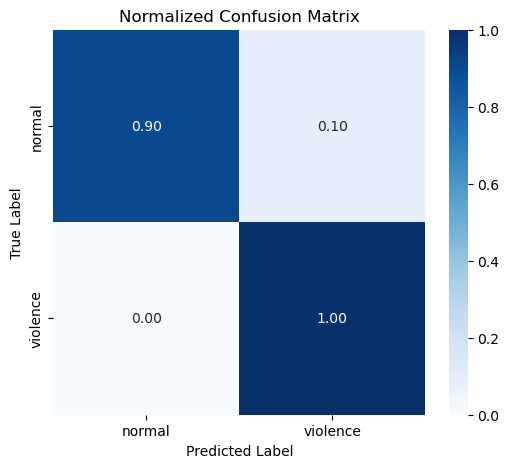

✅ Confusion matrix saved to: models/confusion_matrix.png


In [10]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

from ops.models import TSN
from ops.dataset import TSNDataSet
from ops.transforms import GroupTransform

# --- SETTINGS ---
MODEL_PATH = "models/tsm_best.pth"
SAVE_DIR = "models"
NUM_CLASSES = 2
NUM_SEGMENTS = 12
BATCH_SIZE = 4

CLASS_NAMES = ["normal", "violence"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def generate_cm():
    # 1. Load Model
    print("📥 Loading model weights...")
    model = TSN(num_class=NUM_CLASSES, num_segments=NUM_SEGMENTS)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE).eval()

    # 2. Dataset
    val_dataset = TSNDataSet(
        "dataset/frames",
        "val_list.txt",
        num_segments=NUM_SEGMENTS,
        transform=GroupTransform(is_train=False)
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    # 3. Inference
    all_preds = []
    all_targets = []

    print("🚀 Running inference on validation set...")

    with torch.no_grad():
        for i, (inputs, targets) in enumerate(val_loader):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())

            if i % 10 == 0:
                print(f"Processing batch {i}...")

    # 4. Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)

    # Normalize
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    # 5. Plot
    plt.figure(figsize=(6, 5))  # smaller since only 2 classes
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title("Normalized Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")

    # 6. Save
    os.makedirs(SAVE_DIR, exist_ok=True)
    save_path = os.path.join(SAVE_DIR, "confusion_matrix.png")

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Confusion matrix saved to: {save_path}")

    torch.cuda.empty_cache()


if __name__ == "__main__":
    generate_cm()